In this project, we aim to analyze customer behavior and build a predictive model to identify churn. Customer churn—the likelihood that a customer will stop using a service—is a critical metric for businesses, as retaining existing customers is often more cost-effective than acquiring new ones.

The workflow begins with data preprocessing, where we clean the dataset, handle missing values, and engineer relevant features to better represent customer behavior. We then perform exploratory data analysis (EDA) to uncover patterns and relationships between variables that may influence churn.

Following this, we apply machine learning models to predict whether a customer is likely to churn. Model performance is evaluated using appropriate metrics such as accuracy, F1-score, and ROC-AUC to ensure a balanced and reliable assessment. The ultimate goal is to build a model that not only performs well statistically but also provides meaningful insights that can support business decision-making.


In [106]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time 
import numpy as np


We began by checking the dataset for duplicates and missing values to ensure data quality. After identifying gaps, we merged the relevant datasets into a single dataframe and filled in missing values where necessary. We then created new features to better capture meaningful patterns in the data. Categorical variables were encoded using appropriate techniques, such as one-hot encoding, to make them suitable for machine learning models while avoiding multicollinearity. The target variable was also properly defined by converting churn into a binary indicator. Finally, the data was split into training and testing sets, and scaling was applied to numerical features where appropriate to improve model performance and stability.

In [107]:




contract_data = pd.read_csv("datasets/final_provider/contract.csv")
personal_data = pd.read_csv("datasets/final_provider/personal.csv")
internet_data = pd.read_csv("datasets/final_provider/internet.csv")
phone_data = pd.read_csv("datasets/final_provider/phone.csv")


print("=== Contract Data Columns ===")
print(contract_data.columns)

print("\n=== Personal Data Columns ===")
print(personal_data.columns)

print("\n=== Internet Data Columns ===")
print(internet_data.columns)

print("\n=== Phone Data Columns ===")
print(phone_data.columns)

=== Contract Data Columns ===
Index(['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')

=== Personal Data Columns ===
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents'], dtype='object')

=== Internet Data Columns ===
Index(['customerID', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'],
      dtype='object')

=== Phone Data Columns ===
Index(['customerID', 'MultipleLines'], dtype='object')


In [108]:
print(contract_data['EndDate'])

0                        No
1                        No
2       2019-12-01 00:00:00
3                        No
4       2019-11-01 00:00:00
               ...         
7038                     No
7039                     No
7040                     No
7041    2019-11-01 00:00:00
7042                     No
Name: EndDate, Length: 7043, dtype: object


In [109]:

print("contract_data nulls:\n", contract_data.isnull().sum(), "\n")

print("personal_data nulls:\n", personal_data.isnull().sum(), "\n")

print("internet_data nulls:\n", internet_data.isnull().sum(), "\n")

print("phone_data nulls:\n", phone_data.isnull().sum(), "\n")


contract_data nulls:
 customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64 

personal_data nulls:
 customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64 

internet_data nulls:
 customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64 

phone_data nulls:
 customerID       0
MultipleLines    0
dtype: int64 



In [110]:
print(contract_data.duplicated().sum())
print(personal_data.duplicated().sum())
print(internet_data.duplicated().sum())
print(phone_data.duplicated().sum())

0
0
0
0


In [111]:
df = contract_data.merge(personal_data, on='customerID', how='left')
df = df.merge(internet_data, on='customerID', how='left') 
df = df.merge(phone_data, on='customerID', how='left')

print("Null values per column:")
print(df.isnull().sum())
print(df.shape)




Null values per column:
customerID             0
BeginDate              0
EndDate                0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
dtype: int64
(7043, 20)


In [112]:
internet_cols = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

phone_cols = ['MultipleLines']

df[internet_cols] = df[internet_cols].fillna('No')
df[phone_cols] = df[phone_cols].fillna('No')
print("Null values per column:")
print(df.isnull().sum())
print(df.shape)

Null values per column:
customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
dtype: int64
(7043, 20)


In [113]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Null values per column:")
print(df.isnull().sum())
print(df.shape)

Null values per column:
customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
dtype: int64
(7043, 20)


In [114]:
df['BeginDate'] = pd.to_datetime(df['BeginDate'])



df['churn'] = (df['EndDate'] != 'No').astype(int)


snapshot_date = df['BeginDate'].max()

df['tenure_days'] = (snapshot_date - df['BeginDate']).dt.days

# Numeric fix
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# print(df)
print(df.columns)


Index(['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender',
       'SeniorCitizen', 'Partner', 'Dependents', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'MultipleLines', 'churn',
       'tenure_days'],
      dtype='object')


In [115]:
print(df.head())
print(df.info())
print(df.shape)
print(df.describe())


   customerID  BeginDate              EndDate            Type  \
0  7590-VHVEG 2020-01-01                   No  Month-to-month   
1  5575-GNVDE 2017-04-01                   No        One year   
2  3668-QPYBK 2019-10-01  2019-12-01 00:00:00  Month-to-month   
3  7795-CFOCW 2016-05-01                   No        One year   
4  9237-HQITU 2019-09-01  2019-11-01 00:00:00  Month-to-month   

  PaperlessBilling              PaymentMethod  MonthlyCharges  TotalCharges  \
0              Yes           Electronic check           29.85         29.85   
1               No               Mailed check           56.95       1889.50   
2              Yes               Mailed check           53.85        108.15   
3               No  Bank transfer (automatic)           42.30       1840.75   
4              Yes           Electronic check           70.70        151.65   

   gender  SeniorCitizen  ... InternetService OnlineSecurity OnlineBackup  \
0  Female              0  ...             DSL            

In [116]:
churn = df['churn']
features = df.drop(['churn', 'customerID', 'EndDate', 'BeginDate'], axis=1)
print(features.columns)


Index(['Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines',
       'tenure_days'],
      dtype='object')


In [117]:

print(churn.head())




0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64


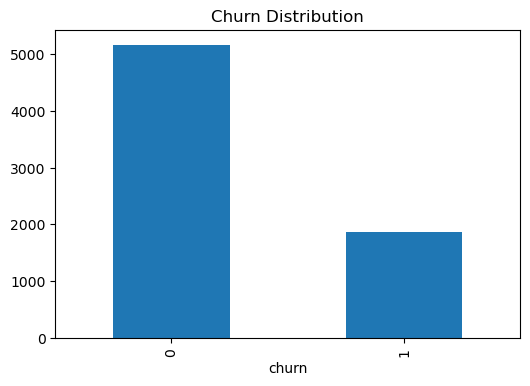

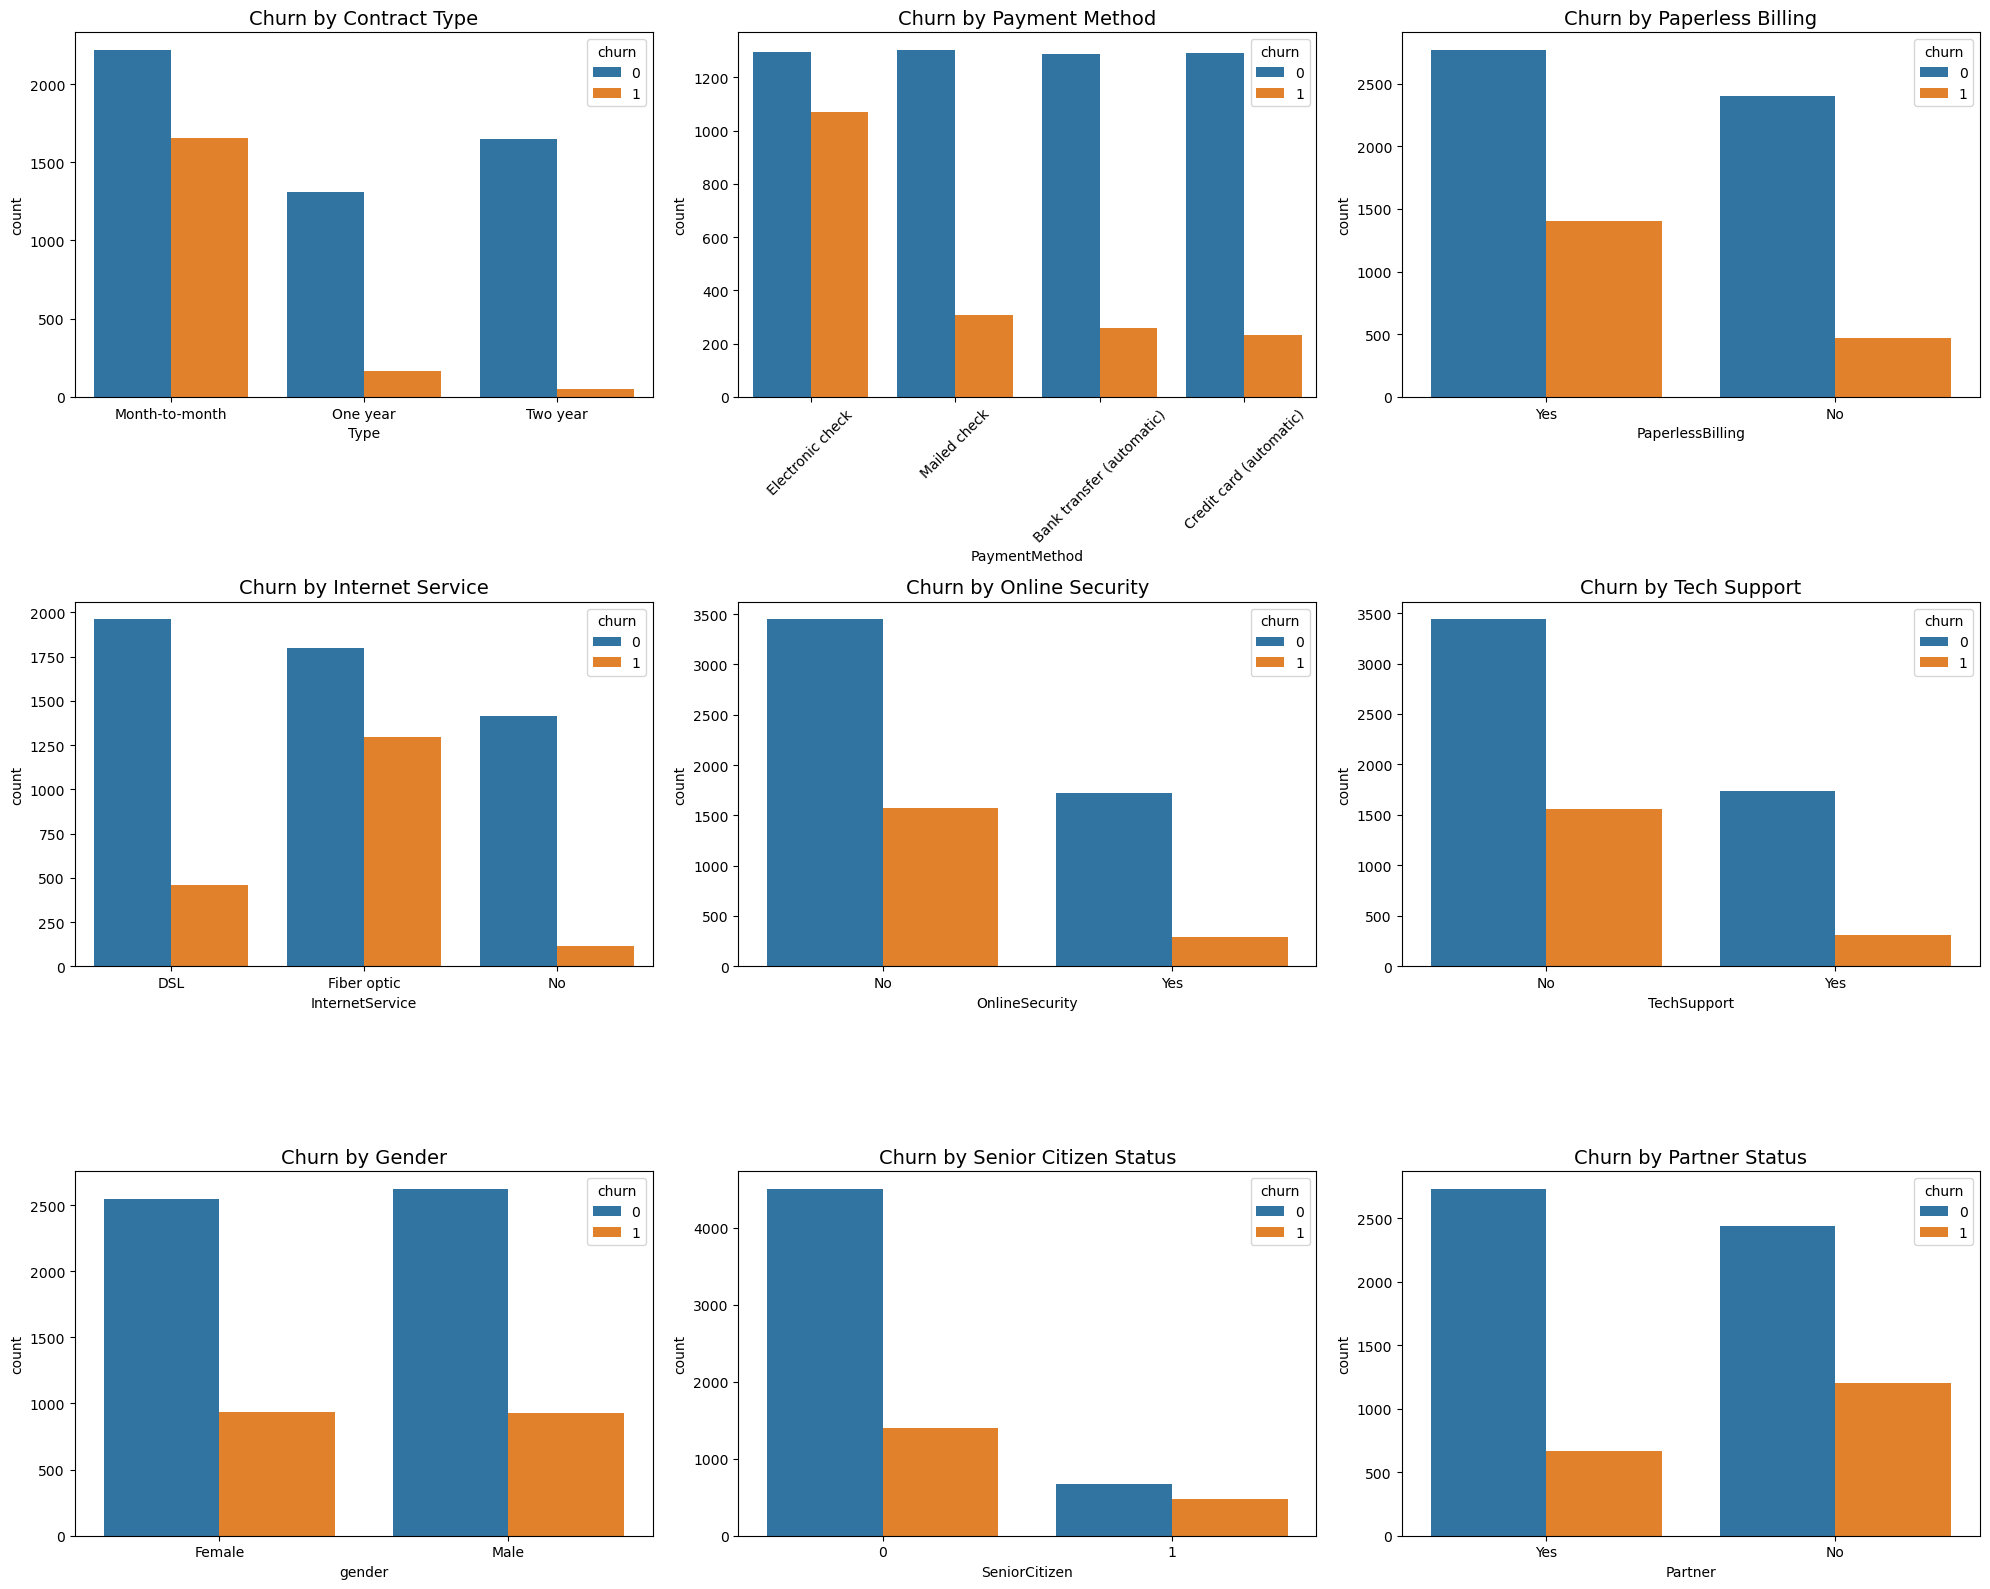

In [118]:
df['churn'].value_counts(normalize=True)
plt.figure(figsize=(6, 4))
df['churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.show()



fig, axes = plt.subplots(3, 3, figsize=(20, 16))

# Row 1: Contract and Payment Features (most impactful)
sns.countplot(data=df, x='Type', hue='churn', ax=axes[0,0])
axes[0,0].set_title('Churn by Contract Type', fontsize=14)

sns.countplot(data=df, x='PaymentMethod', hue='churn', ax=axes[0,1])
axes[0,1].set_title('Churn by Payment Method', fontsize=14)
axes[0,1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='PaperlessBilling', hue='churn', ax=axes[0,2])
axes[0,2].set_title('Churn by Paperless Billing', fontsize=14)

# Row 2: Service Features
sns.countplot(data=df, x='InternetService', hue='churn', ax=axes[1,0])
axes[1,0].set_title('Churn by Internet Service', fontsize=14)

sns.countplot(data=df, x='OnlineSecurity', hue='churn', ax=axes[1,1])
axes[1,1].set_title('Churn by Online Security', fontsize=14)

sns.countplot(data=df, x='TechSupport', hue='churn', ax=axes[1,2])
axes[1,2].set_title('Churn by Tech Support', fontsize=14)

# Row 3: Demographics (including gender)
sns.countplot(data=df, x='gender', hue='churn', ax=axes[2,0])
axes[2,0].set_title('Churn by Gender', fontsize=14)

sns.countplot(data=df, x='SeniorCitizen', hue='churn', ax=axes[2,1])
axes[2,1].set_title('Churn by Senior Citizen Status', fontsize=14)

sns.countplot(data=df, x='Partner', hue='churn', ax=axes[2,2])
axes[2,2].set_title('Churn by Partner Status', fontsize=14)

plt.tight_layout()
plt.show()


The analysis indicates that churn is primarily driven by contract type, payment method, and service-related features. Customers on month-to-month contracts, those using electronic check payments, and those lacking additional services such as online security and tech support exhibit significantly higher churn rates. Fiber optic users also demonstrate elevated churn, potentially reflecting higher expectations or pricing sensitivity. Additionally, senior customers, paperless billing users, and those without partners show moderately higher churn rates. In contrast, gender does not appear to have a meaningful impact on churn behavior.

In [119]:

categorical_cols = features.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# Apply get_dummies to all categorical columns at once
features_encoded = pd.get_dummies(features, columns=categorical_cols, drop_first=True)
print("Shape before encoding:", features.shape)
print("Shape after encoding:", features_encoded.shape)



Categorical columns to encode: ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
Shape before encoding: (7043, 18)
Shape after encoding: (7043, 22)


In [120]:

X_temp, X_test, y_temp, y_test = train_test_split(
    features_encoded, churn, 
    test_size=0.2, 
    random_state=42, 
    stratify=churn  # This ensures balanced splits
)

# Second split: divide remaining 80% into train (60% of total) and validation (20% of total)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, 
    test_size=0.25,  # 0.25 * 0.8 = 0.2 (20% of original data)
    random_state=42,
    stratify=y_temp
)

print("Dataset splits:")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(features_encoded)*100:.1f}%)")
print(f"Validation set: {X_valid.shape[0]} samples ({X_valid.shape[0]/len(features_encoded)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(features_encoded)*100:.1f}%)")

# Check class distribution in each split
print("\nClass distribution:")
print(f"Train - Churn rate: {y_train.mean():.3f}")
print(f"Valid - Churn rate: {y_valid.mean():.3f}")
print(f"Test - Churn rate: {y_test.mean():.3f}")


Dataset splits:
Training set: 4225 samples (60.0%)
Validation set: 1409 samples (20.0%)
Test set: 1409 samples (20.0%)

Class distribution:
Train - Churn rate: 0.265
Valid - Churn rate: 0.265
Test - Churn rate: 0.265


In [121]:
num_cols = ['MonthlyCharges', 'TotalCharges', 'tenure_days']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_valid_scaled = X_valid.copy()  # Add this line!
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_valid_scaled[num_cols] = scaler.transform(X_valid_scaled[num_cols])  # Add this line!
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])

In [122]:
print(features.head)

<bound method NDFrame.head of                 Type PaperlessBilling              PaymentMethod  \
0     Month-to-month              Yes           Electronic check   
1           One year               No               Mailed check   
2     Month-to-month              Yes               Mailed check   
3           One year               No  Bank transfer (automatic)   
4     Month-to-month              Yes           Electronic check   
...              ...              ...                        ...   
7038        One year              Yes               Mailed check   
7039        One year              Yes    Credit card (automatic)   
7040  Month-to-month              Yes           Electronic check   
7041  Month-to-month              Yes               Mailed check   
7042        Two year              Yes  Bank transfer (automatic)   

      MonthlyCharges  TotalCharges  gender  SeniorCitizen Partner Dependents  \
0              29.85         29.85  Female              0     Yes        

In [123]:
df[num_cols].describe()

,MonthlyCharges,TotalCharges,tenure_days
count,7043.000000,7043.000000,7043.000000
mean,64.761692,2279.734304,1006.457050
std,30.090047,2266.794470,736.596428
min,18.250000,0.000000,0.000000
25%,35.500000,398.550000,306.000000
50%,70.350000,1394.550000,883.000000
75%,89.850000,3786.600000,1706.000000
max,118.750000,8684.800000,2314.000000


In [124]:
# First, let's identify all categorical columns
categorical_cols = features.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# Apply get_dummies to all categorical columns at once
features_encoded = pd.get_dummies(features, columns=categorical_cols, drop_first=True)
print("Shape before encoding:", features.shape)
print("Shape after encoding:", features_encoded.shape)

Categorical columns to encode: ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
Shape before encoding: (7043, 18)
Shape after encoding: (7043, 22)


        C penalty  accuracy_valid  f1_valid  roc_auc_valid  train_time_sec
1    0.01      l2        0.753016  0.624190       0.826327          0.0571
5    1.00      l2        0.740241  0.615546       0.830383          0.0572
4    1.00      l1        0.738112  0.613613       0.830406          0.1784
2    0.10      l1        0.733144  0.613169       0.831123          0.1156
8  100.00      l1        0.737402  0.612971       0.829939          0.1795
6   10.00      l1        0.737402  0.612971       0.829972          0.3206
9  100.00      l2        0.737402  0.612971       0.829954          0.0616
7   10.00      l2        0.737402  0.612971       0.829952          0.1566
3    0.10      l2        0.738822  0.610169       0.831199          0.0724
0    0.01      l1        0.711852  0.590726       0.808158          0.0781


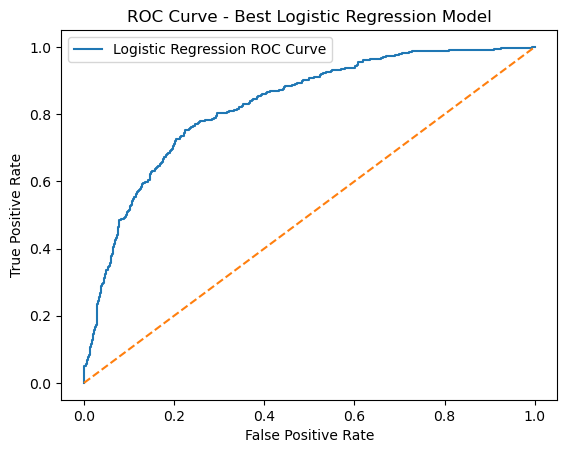

Best Logistic Regression model (based on validation set):
Parameters → C=0.01, penalty='l2'
Validation Metrics → Accuracy=0.7530, F1=0.6242, ROC-AUC=0.8263
Training Time → 0.0571 seconds
Confusion matrix:
[[772 263]
 [ 85 289]]


In [125]:
results = []

for C in [0.01, 0.1, 1, 10, 100]:
    for penalty in ['l1', 'l2']:
        model = LogisticRegression(
            random_state=12345,
            solver='liblinear',
            penalty=penalty,
            C=C,
            max_iter=1000,
    class_weight='balanced'
        )
        
        start_time = time.time()
        model.fit(X_train_scaled, y_train)
        train_time = time.time() - start_time
        
        y_valid_pred = model.predict(X_valid_scaled)
        y_valid_prob = model.predict_proba(X_valid_scaled)[:, 1]
        
        results.append({
            'C': C,
            'penalty': penalty,
            'accuracy_valid': accuracy_score(y_valid, y_valid_pred),
            'f1_valid': f1_score(y_valid, y_valid_pred),
            'roc_auc_valid': roc_auc_score(y_valid, y_valid_prob),
            'train_time_sec': round(train_time, 4)
        })
results_df = pd.DataFrame(results).sort_values(by='f1_valid', ascending=False)
print(results_df)
best_row = results_df.iloc[0]

best_C = best_row['C']
best_penalty = best_row['penalty']

# print("Best params: C=", best_C, ", penalty=", best_penalty)

best_model = LogisticRegression(
    random_state=12345,
    solver='liblinear',
    penalty=best_penalty,
    C=best_C,
    max_iter=1000,
    class_weight='balanced'
)

best_model.fit(X_train_scaled, y_train)

y_valid_pred = best_model.predict(X_valid_scaled)
y_valid_prob = best_model.predict_proba(X_valid_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_valid, y_valid_prob)

plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Logistic Regression Model')
plt.legend()
plt.show()


# print("Validation Accuracy:", accuracy_score(y_valid, y_valid_pred))
# print("Validation F1:", f1_score(y_valid, y_valid_pred))
# print("Validation ROC-AUC:", roc_auc_score(y_valid, y_valid_prob))
# print("Confusion matrix:\n", confusion_matrix(y_valid, y_valid_pred))
best_f1 = best_row['f1_valid']
best_auc = best_row['roc_auc_valid']
best_acc = best_row['accuracy_valid']
best_time = best_row['train_time_sec']

print("="*50)
print("Best Logistic Regression model (based on validation set):")
print(f"Parameters → C={best_C}, penalty='{best_penalty}'")
print(f"Validation Metrics → Accuracy={best_acc:.4f}, F1={best_f1:.4f}, ROC-AUC={best_auc:.4f}")
print(f"Training Time → {best_time:.4f} seconds")
print("Confusion matrix:")
print(confusion_matrix(y_valid, y_valid_pred))
print("="*50)


     max_depth  min_samples_split  min_samples_leaf  accuracy_valid  f1_valid  \
110        NaN                 20                 5        0.803407  0.664242   
98         NaN                  2                 5        0.797019  0.662736   
106        NaN                 10                 5        0.797019  0.662736   
102        NaN                  5                 5        0.797019  0.662736   
104        NaN                 10                 1        0.804116  0.658416   
96         NaN                  2                 1        0.821859  0.654746   
100        NaN                  5                 1        0.814053  0.654354   
103        NaN                  5                10        0.787083  0.652778   
111        NaN                 20                10        0.787083  0.652778   
107        NaN                 10                10        0.787083  0.652778   

     roc_auc_valid  train_time_sec  inference_time_sec  
110       0.853153          0.0938              0.0

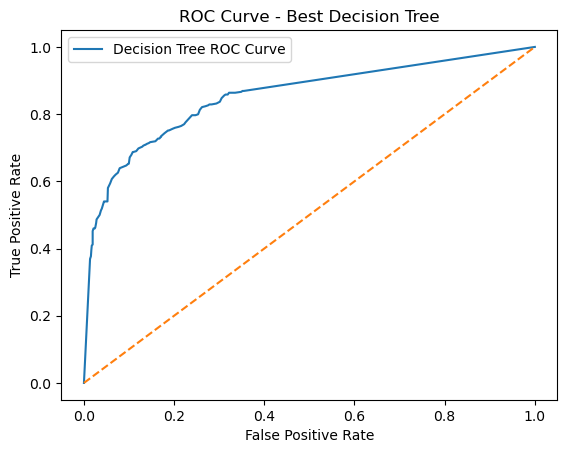

Best Decision Tree model (based on validation set):
Parameters → max_depth=None, min_samples_split=20, min_samples_leaf=5
Validation Metrics → Accuracy=0.8034, F1=0.6642, ROC-AUC=0.8532
Training Time → 0.0938 seconds
Inference Time → 0.0171 seconds
Confusion matrix:
[[858 177]
 [100 274]]


In [126]:

results = []

for max_depth in [2, 3, 4, 5, 7, 10, None]:
    for min_samples_split in [2, 5, 10, 20]:
        for min_samples_leaf in [1, 2, 5, 10]:

            model = DecisionTreeClassifier(
                random_state=12345,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
    class_weight='balanced'
            )

            start_time = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - start_time

            start_time = time.time()
            y_valid_pred = model.predict(X_valid)
            y_valid_prob = model.predict_proba(X_valid)[:, 1]
            inference_time = time.time() - start_time

            results.append({
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'accuracy_valid': accuracy_score(y_valid, y_valid_pred),
                'f1_valid': f1_score(y_valid, y_valid_pred),
                'roc_auc_valid': roc_auc_score(y_valid, y_valid_prob),
                'train_time_sec': round(train_time, 4),
                'inference_time_sec': round(inference_time, 4)
            })

results_df = pd.DataFrame(results).sort_values(by='f1_valid', ascending=False)

print(results_df.head(10))

best_row = results_df.iloc[0]

best_depth = best_row['max_depth']

# Convert pandas NaN back to Python None
if pd.isna(best_depth):
    best_depth = None
else:
    best_depth = int(best_depth)

best_split = int(best_row['min_samples_split'])
best_leaf = int(best_row['min_samples_leaf'])

best_tree = DecisionTreeClassifier(
    random_state=12345,
    max_depth=best_depth,
    min_samples_split=best_split,
    min_samples_leaf=best_leaf,
    class_weight='balanced'
)

best_tree.fit(X_train, y_train)

y_valid_pred = best_tree.predict(X_valid)
y_valid_prob = best_tree.predict_proba(X_valid)[:, 1]
fpr, tpr, thresholds = roc_curve(y_valid, y_valid_prob)

plt.figure()
plt.plot(fpr, tpr, label='Decision Tree ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Decision Tree')
plt.legend()
plt.show()

print("="*50)
print("Best Decision Tree model (based on validation set):")
print(f"Parameters → max_depth={best_depth}, min_samples_split={best_split}, min_samples_leaf={best_leaf}")
print(f"Validation Metrics → Accuracy={accuracy_score(y_valid, y_valid_pred):.4f}, F1={f1_score(y_valid, y_valid_pred):.4f}, ROC-AUC={roc_auc_score(y_valid, y_valid_prob):.4f}")
print(f"Training Time → {best_row['train_time_sec']:.4f} seconds")
print(f"Inference Time → {best_row['inference_time_sec']:.4f} seconds")
print("Confusion matrix:")
print(confusion_matrix(y_valid, y_valid_pred))
print("="*50)


    n_estimators  max_depth  min_samples_leaf max_features  accuracy_valid  \
76           300       20.0                 5         sqrt        0.813343   
77           300       20.0                 5         log2        0.813343   
82           300       25.0                 5         sqrt        0.812633   
83           300       25.0                 5         log2        0.812633   
88           300        NaN                 5         sqrt        0.812633   
89           300        NaN                 5         log2        0.812633   
47           200       20.0                 5         log2        0.811923   
46           200       20.0                 5         sqrt        0.811923   
58           200        NaN                 5         sqrt        0.811214   
59           200        NaN                 5         log2        0.811214   

    f1_valid  roc_auc_valid  train_time_sec  inference_time_sec  
76  0.681983       0.865483          5.3921              1.5288  
77  0.681

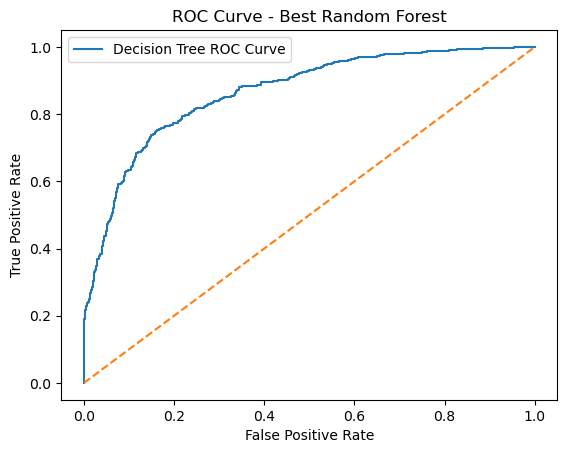

Best Random Forest model (based on validation set):
Parameters → n_estimators=300, max_depth=20, min_samples_leaf=5, max_features='sqrt'
Validation Metrics → Accuracy=0.8133, F1=0.6820, ROC-AUC=0.8655
Training Time → 5.3921 seconds
Inference Time → 1.7260 seconds
Confusion matrix:
[[864 171]
 [ 92 282]]


In [127]:

results = []

for n_estimators in [100, 200, 300]:
    for max_depth in [10, 15, 20, 25, None]:
        for min_samples_leaf in [1, 2, 5]:
            for max_features in ['sqrt', 'log2']:

                model = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    bootstrap=True,
                    class_weight='balanced',
                    random_state=12345,
                    n_jobs=-1
                )

                start_time = time.time()
                model.fit(X_train, y_train)
                train_time = time.time() - start_time

                start_time = time.time()
                y_valid_pred = model.predict(X_valid)
                y_valid_prob = model.predict_proba(X_valid)[:, 1]
                inference_time = time.time() - start_time

                results.append({
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_leaf': min_samples_leaf,
                    'max_features': max_features,
                    'accuracy_valid': accuracy_score(y_valid, y_valid_pred),
                    'f1_valid': f1_score(y_valid, y_valid_pred),
                    'roc_auc_valid': roc_auc_score(y_valid, y_valid_prob),
                    'train_time_sec': round(train_time, 4),
                    'inference_time_sec': round(inference_time, 4)
                })

results_df = pd.DataFrame(results).sort_values(by='f1_valid', ascending=False)

print(results_df.head(10))

best_row = results_df.iloc[0]

best_n_estimators = int(best_row['n_estimators'])

best_depth = best_row['max_depth']
if pd.isna(best_depth):
    best_depth = None
else:
    best_depth = int(best_depth)

best_leaf = int(best_row['min_samples_leaf'])
best_features = best_row['max_features']

best_forest = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    max_features=best_features,
    bootstrap=True,
    class_weight='balanced',
    random_state=12345,
    n_jobs=-1
)

best_forest.fit(X_train, y_train)

start_time = time.time()
y_valid_pred = best_forest.predict(X_valid)
y_valid_prob = best_forest.predict_proba(X_valid)[:, 1]
fpr, tpr, thresholds = roc_curve(y_valid, y_valid_prob)

plt.figure()
plt.plot(fpr, tpr, label='Decision Tree ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Random Forest')
plt.legend()
plt.show()
inference_time = time.time() - start_time

print("="*50)
print("Best Random Forest model (based on validation set):")
print(f"Parameters → n_estimators={best_n_estimators}, max_depth={best_depth}, min_samples_leaf={best_leaf}, max_features='{best_features}'")
print(f"Validation Metrics → Accuracy={accuracy_score(y_valid, y_valid_pred):.4f}, F1={f1_score(y_valid, y_valid_pred):.4f}, ROC-AUC={roc_auc_score(y_valid, y_valid_prob):.4f}")
print(f"Training Time → {best_row['train_time_sec']:.4f} seconds")
print(f"Inference Time → {inference_time:.4f} seconds")
print("Confusion matrix:")
print(confusion_matrix(y_valid, y_valid_pred))
print("="*50)

    learning_rate  n_estimators  num_leaves  min_child_samples  \
80           0.05          2000          63                 50   
52           0.03          2000          63                 30   
68           0.05          1000          31                 50   
77           0.05          2000          31                 50   
26           0.01          2000          63                 50   
49           0.03          2000          31                 30   
33           0.03           500          63                 20   
57           0.05           500          31                 20   
50           0.03          2000          31                 50   
79           0.05          2000          63                 30   

    accuracy_valid  f1_valid  roc_auc_valid  train_time_sec  \
80        0.903478  0.807365       0.932597         17.2729   
52        0.902058  0.804533       0.931951         23.5001   
68        0.899929  0.803894       0.933307          6.1704   
77        0.901348  0

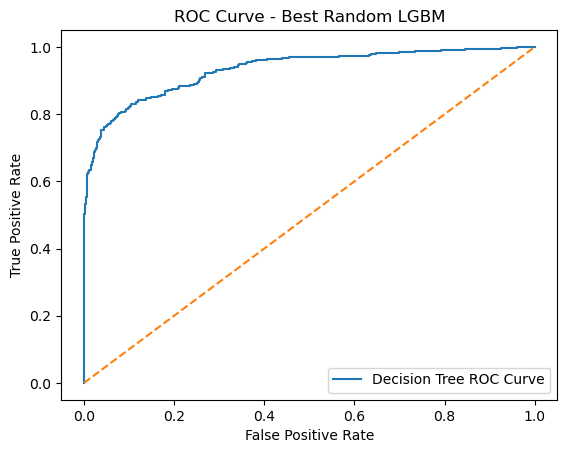

Best LightGBM model (based on validation set):
Parameters → learning_rate=0.05, n_estimators=2000, num_leaves=63, min_child_samples=50
Validation Metrics → Accuracy=0.9035, F1=0.8074, ROC-AUC=0.9326
Training Time → 17.2729 seconds
Inference Time → 0.3213 seconds
Confusion matrix:
[[988  47]
 [ 89 285]]


In [131]:
results = []

for learning_rate in [0.01, 0.03, 0.05]:
    for n_estimators in [500, 1000, 2000]:
        for num_leaves in [15, 31, 63]:
            for min_child_samples in [20, 30, 50]:

                model = LGBMClassifier(
                    learning_rate=learning_rate,
                    n_estimators=n_estimators,
                    num_leaves=num_leaves,
                    min_child_samples=min_child_samples,
                    subsample=0.8,
                    subsample_freq=1,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=0.1,
                    class_weight='balanced',
                    random_state=42,
                    verbosity=-1

                )

                start_time = time.time()
                model.fit(X_train, y_train)
                train_time = time.time() - start_time

                start_time = time.time()
                y_valid_pred = model.predict(X_valid)
                y_valid_prob = model.predict_proba(X_valid)[:, 1]
                inference_time = time.time() - start_time

                results.append({
                    'learning_rate': learning_rate,
                    'n_estimators': n_estimators,
                    'num_leaves': num_leaves,
                    'min_child_samples': min_child_samples,
                    'accuracy_valid': accuracy_score(y_valid, y_valid_pred),
                    'f1_valid': f1_score(y_valid, y_valid_pred),
                    'roc_auc_valid': roc_auc_score(y_valid, y_valid_prob),
                    'train_time_sec': round(train_time, 4),
                    'inference_time_sec': round(inference_time, 4)
                })

results_df = pd.DataFrame(results).sort_values(by='f1_valid', ascending=False)

print(results_df.head(10))

best_row = results_df.iloc[0]

best_lgbm = LGBMClassifier(
    learning_rate=best_row['learning_rate'],
    n_estimators=int(best_row['n_estimators']),
    num_leaves=int(best_row['num_leaves']),
    min_child_samples=int(best_row['min_child_samples']),
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    random_state=42, 
    verbose=-1
)

best_lgbm.fit(X_train, y_train)

y_valid_pred = best_lgbm.predict(X_valid)
y_valid_prob = best_lgbm.predict_proba(X_valid)[:, 1]
fpr, tpr, thresholds = roc_curve(y_valid, y_valid_prob)

plt.figure()
plt.plot(fpr, tpr, label='Decision Tree ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Random LGBM')
plt.legend()
plt.show()

print("="*50)
print("Best LightGBM model (based on validation set):")
print(
    f"Parameters → learning_rate={best_row['learning_rate']}, "
    f"n_estimators={int(best_row['n_estimators'])}, "
    f"num_leaves={int(best_row['num_leaves'])}, "
    f"min_child_samples={int(best_row['min_child_samples'])}"
)
print(
    f"Validation Metrics → Accuracy={accuracy_score(y_valid, y_valid_pred):.4f}, "
    f"F1={f1_score(y_valid, y_valid_pred):.4f}, "
    f"ROC-AUC={roc_auc_score(y_valid, y_valid_prob):.4f}"
)
print(f"Training Time → {best_row['train_time_sec']:.4f} seconds")
print(f"Inference Time → {best_row['inference_time_sec']:.4f} seconds")
print("Confusion matrix:")
print(confusion_matrix(y_valid, y_valid_pred))
print("="*50)


Final LightGBM Test Results:
Test Accuracy → 0.9013
Test F1 → 0.8034
Test ROC-AUC → 0.9439


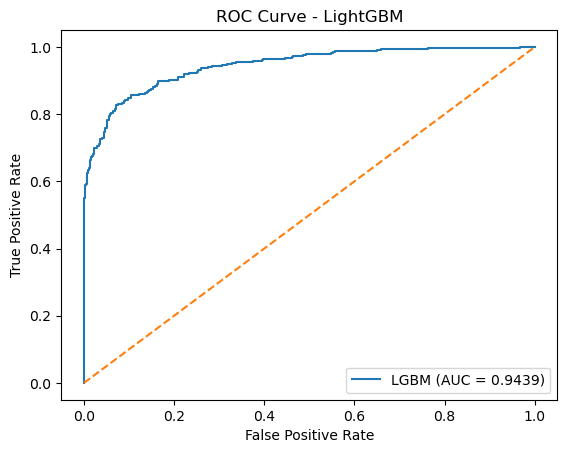

Test Inference Time → 0.3575 seconds
Confusion matrix:
[[986  49]
 [ 90 284]]


In [129]:
start_time = time.time()

y_test_pred = best_lgbm.predict(X_test)
y_test_prob = best_lgbm.predict_proba(X_test)[:, 1]

test_inference_time = time.time() - start_time

print("="*50)
print("Final LightGBM Test Results:")
print(f"Test Accuracy → {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test F1 → {f1_score(y_test, y_test_pred):.4f}")
print(f"Test ROC-AUC → {roc_auc_score(y_test, y_test_prob):.4f}")
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"LGBM (AUC = {roc_auc_score(y_test, y_test_prob):.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend()

plt.show()
print(f"Test Inference Time → {test_inference_time:.4f} seconds")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("="*50)

Conclusion
In this project, multiple machine learning models were developed and evaluated to predict customer churn, including Logistic Regression, Decision Tree, Random Forest, and LightGBM. All models were tuned using a validation set, and the final evaluation was performed on a held-out test set to ensure an unbiased assessment of performance.

Among all models, the tuned LightGBM model achieved the best overall results. On the validation set, it reached an accuracy of 0.9035, an F1 score of 0.8074, and a ROC-AUC of 0.9326. When evaluated on the test set, it maintained very strong and consistent performance, with an accuracy of 0.9013, an F1 score of 0.8034, and a ROC-AUC of 0.9439. The small difference between validation and test metrics indicates that the model generalizes well and does not suffer from significant overfitting.

Logistic Regression, used as a baseline model, achieved lower performance due to its linear nature. Even after tuning, it was unable to capture the complex relationships in the data, resulting in a noticeably lower F1 score compared to tree-based models. While it provided a useful benchmark, its simplicity limited its effectiveness for this task.

The Decision Tree model improved performance over Logistic Regression by capturing non-linear patterns, achieving a higher F1 score. However, it remained prone to overfitting and instability, especially when allowed to grow deep, even with regularization parameters such as minimum samples per leaf.

The Random Forest model further improved robustness by averaging multiple trees, reducing variance and improving generalization. It achieved stronger performance than a single Decision Tree but still did not match LightGBM, particularly in terms of F1 score and ROC-AUC.

F1 score was selected as the primary evaluation metric due to class imbalance in the dataset, where non-churn customers significantly outnumber churn customers. Accuracy alone can be misleading in such cases, while F1 provides a better balance between precision and recall. This is especially important in a business context, where both missing a potential churner (false negative) and incorrectly targeting a loyal customer (false positive) have associated costs.

Overall, the tuned LightGBM model was selected as the final model because it achieved the highest F1 score and ROC-AUC on the validation set and maintained this performance on the test set. Its ability to model complex, non-linear relationships and generalize well to unseen data makes it the most reliable choice for predicting customer churn.

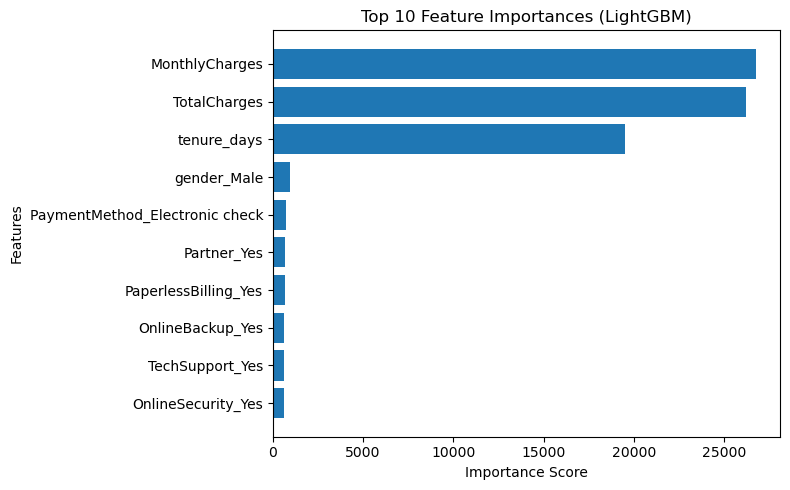

In [130]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_lgbm.feature_importances_
}).sort_values(by='importance', ascending=False)

# Select top 10 features
top_features = feature_importance.head(10)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances (LightGBM)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

Feature importance from the LightGBM model shows that MonthlyCharges, TotalCharges, and tenure are the most influential factors associated with customer churn, highlighting the importance of pricing and the customer lifecycle.

Customers with higher monthly charges and shorter tenure are more likely to churn, indicating that cost sensitivity and early-stage engagement are key risk factors. Additionally, customers using electronic check payments and those without services such as tech support, online security, or backup show higher churn rates, suggesting lower engagement and commitment.

From a business perspective, the company should focus on improving onboarding for new customers to reduce early churn, offering incentives to customers with high monthly charges to address cost sensitivity, promoting additional services to increase engagement, and targeting high-risk payment segments with retention strategies.

Overall, feature importance analysis helps explain not only which customers are likely to churn, but also the key factors associated with churn, enabling more targeted and effective business decisions.


Clarifying Questions:

What is the target variable and how is churn defined?

Are there missing values, duplicates, or inconsistencies in the data?

Which features are categorical vs numerical, and which require encoding or scaling?

Is the dataset imbalanced, and do we need to address this during modeling?

Which evaluation metric is most appropriate (e.g., F1 score, ROC-AUC)?


1. Data Exploration

Inspect the dataset structure, feature types, and target distribution. Identify missing values and duplicates to understand data quality.

2. Data Preprocessing

Handle missing values, remove duplicates if necessary, and define the target variable. Encode categorical features and scale numerical variables where appropriate.

3. Exploratory Data Analysis (EDA)

Analyze relationships between features and churn using visualizations. Identify key patterns and potential predictors.

4. Model Training and Evaluation

Split the data into training and testing sets. Train models and evaluate performance using appropriate metrics.

5. Conclusions

Summarize key findings, identify important features, and provide insights or recommendations based on the results.